# Car Count Project 1
## Using yolov8

## Installing dependencies for yolo which is not pre-available in colab

In [ ]:
%pip install ultralytics
%pip install cvzone

  Preparing metadata (setup.py) ... done
  Created wheel for cvzone: filename=cvzone-1.6.1-py3-none-any.whl size=26298 sha256=e4489df86aaf135f2b046146b4f8d896064ae9a5791755799ce706727e09b15f
  Stored in directory: /root/.cache/pip/wheels/5d/21/e8/3147ae88d44e27f06e0175d337a7673c70fb957202cbbe2034
Successfully built cvzone


## Importing required libraries

In [ ]:
from ultralytics import YOLO
import cv2
import cvzone
import math
import csv
import numpy as np
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Mounting drive for model and video_file

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Model

In [ ]:
# importing model weights
model = YOLO("/content/drive/MyDrive/Object_detection/Model_Weight/yolov8n.pt")

## Check cuda availibility

In [ ]:
# Check if CUDA is available and set the device accordingly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model.to(device)

Using device: cuda


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## Importing total class from csv file and add it into list for future use

In [ ]:
# for total class
total_class = []
with open("/content/drive/MyDrive/Object_detection/classes.csv", mode="r") as file:
    reader = csv.reader(file)
    next(reader)   # skipping heading
    for row in reader:
        total_class.append(row[0])

## Cloning the repo for sort.py which is used to track the car

In [ ]:
# cloning repo
!git clone https://github.com/abewley/sort.git

Cloning into 'sort'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 208 (delta 45), reused 40 (delta 40), pack-reused 159 (from 1)
Receiving objects: 100% (208/208), 1.20 MiB | 26.79 MiB/s, done.
Resolving deltas: 100% (76/76), done.


## Installing dependencies required for sort.py

In [ ]:
!pip install filterpy==1.4.5
!pip install lap>=0.5.0
!pip install scikit-image>=0.19.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=aa4890e0a533a4056432a55a81bf4da8c84fec8e5a4915473556741432d07aa0
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


## Adding sort to the system path

In [ ]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()
# Assuming 'sort' is cloned into the current directory
sort_path = os.path.join(current_dir, 'sort')

# Add the 'sort' directory to the system path if it's not already there
if sort_path not in sys.path:
    sys.path.append(sort_path)

# Verify the path has been added (optional)
print(f"sys.path after adding sort directory: {sys.path}")

sys.path after adding sort directory: ['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/sort']


## Since sort.py is trying to use a matplotlib backend called 'TkAgg', which requires a graphical user interface (GUI). Colab runs in a headless environment, meaning it doesn't have a GUI. we need to change the matplotlib backend.

In [ ]:
%cd sort
!sed -i "s/matplotlib.use('TkAgg')/matplotlib.use('Agg')/" sort.py
%cd ..

/content/sort
/content


## Reload the modified sort

In [ ]:
import importlib
import sort
importlib.reload(sort)

<module 'sort' from '/content/sort/sort.py'>

## Import everything from the sort module

In [ ]:
# Import the Sort class from the sort module
from sort import *

## Defining the tracker

In [ ]:
# tracking
tracker = Sort(max_age=20, min_hits=3, iou_threshold=0.3)

## If Cuda is not available
### saving output in the video form

In [ ]:
# campture the frame and detect
"""cap = cv2.VideoCapture("/content/drive/MyDrive/Object_detection/Dataset/sample_vdo_2.mp4")

# reading the property of the video
frame_width = int(cap.get(3))    # property 3 means width (pixels)
frame_height = int(cap.get(4))   # property 4 means height (pixels)
frame_fps = int(cap.get(5))      # property 5 means fps
print(f"Frame width: {frame_width}")
print(f"Frame height: {frame_height}")
print(f"Frame FPS: {frame_fps}")

# define codec and videowriter object (save frames into a video file)
out = cv2.VideoWriter("output_mask_track.mp4",                          # output file name and format
                      cv2.VideoWriter_fourcc(*'mp4v'),       # video compression format
                      frame_fps, (frame_width, frame_height) # same properties
                      )
print(f"VideoWriter created: output.mp4 with codec {'mp4v'} at {frame_fps} FPS and resolution ({frame_width}, {frame_height})")

mask = cv2.imread("/content/drive/MyDrive/Object_detection/Dataset/mask.png")
try:
    frame_count = 0
    while True:
        success, img = cap.read()
        if not success:  # Check if the frame was read successfully
            print("Failed to read frame from video stream. Ending video processing.")
            break  # Exit the loop if reading failed
        imgRegion = cv2.bitwise_and(img, mask)
        frame_count += 1
        results = model(imgRegion)
        detections = np.empty((0, 5))
        for r in results:
            boxes = r.boxes
            for box in boxes:
                #x1, y1, x2, y2 = box.xyxy[0]
                #x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                #print(x1, y1, x2, y2)
                #cv2.rectangle(img, (x1, y1), (x2, y2), (255,0, 255), 3)   # image, (x1, y1), (x2, y2), (color in rgb), width


                # if you want to use cvzone for fancy recatnge
                x1, y1 , x2 , y2 = box.xyxy[0]
                x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                w, h = x2-x1, y2-y1

                # confidence
                conf = math.ceil(box.conf[0]*100)/100
                #print(conf)
                #cvzone.putTextRect(img, f'{conf}{total_class[clls]}', (max(0,x1),max(30,y1)))
                # class
                clls = int(box.cls[0])
                current_class = total_class[clls]
                if current_class == "car" and conf > 0.3:
                  #cvzone.cornerRect(img, (x1, y1, w, h)) # This cornerRect was for displaying detection boxes, we'll replace it with tracking boxes
                  #cvzone.putTextRect(img, f'{conf}{total_class[clls]}', (max(0,x1),max(30,y1)), scale=0.5, thickness=1) # This text was for displaying detection info, we'll replace it with tracking ID
                  currentArray = np.array([x1, y1, x2, y2, conf])
                  detections = np.vstack((detections, currentArray))

        results = tracker.update(detections)
        for result in results:
          x1, y1, x2, y2, id = result
          x1, y1, x2, y2, id = int(x1), int(y1), int(x2), int(y2), int(id)
          w, h = x2-x1, y2-y1
          cvzone.cornerRect(img, (x1, y1, w, h), l=5, rt=2, colorR=(255,0,0))
          cvzone.putTextRect(img, f'{id}', (max(0,x1),max(30,y1)), scale=2, thickness=2, offset=10) # Adjusted scale and thickness for visibility
        img = cv2.resize(img, (frame_width, frame_height))
        out.write(img)
        if frame_count % 100 == 0:  # Print every 100 frames to avoid too much output
            print(f"Processed and wrote frame {frame_count}")

except KeyboardInterrupt:
    print("Interrupted by user")
finally:
    cap.release()
    out.release() # Release the VideoWriter
    cv2.destroyAllWindows()   """

'cap = cv2.VideoCapture("/content/drive/MyDrive/Object_detection/Dataset/sample_vdo_2.mp4")\n\n# reading the property of the video\nframe_width = int(cap.get(3))    # property 3 means width (pixels)\nframe_height = int(cap.get(4))   # property 4 means height (pixels)\nframe_fps = int(cap.get(5))      # property 5 means fps\nprint(f"Frame width: {frame_width}")\nprint(f"Frame height: {frame_height}")\nprint(f"Frame FPS: {frame_fps}")\n\n# define codec and videowriter object (save frames into a video file)\nout = cv2.VideoWriter("output_mask_track.mp4",                          # output file name and format\n                      cv2.VideoWriter_fourcc(*\'mp4v\'),       # video compression format\n                      frame_fps, (frame_width, frame_height) # same properties\n                      )\nprint(f"VideoWriter created: output.mp4 with codec {\'mp4v\'} at {frame_fps} FPS and resolution ({frame_width}, {frame_height})")\n\nmask = cv2.imread("/content/drive/MyDrive/Object_detectio

## If cuda is available
### saving output in the video form

In [ ]:
# campture the frame and detect
cap = cv2.VideoCapture("/content/drive/MyDrive/Object_detection/Dataset/sample_vdo_2.mp4")

# reading the property of the video
frame_width = int(cap.get(3))    # property 3 means width (pixels)
frame_height = int(cap.get(4))   # property 4 means height (pixels)
frame_fps = int(cap.get(5))      # property 5 means fps
print(f"Frame width: {frame_width}")
print(f"Frame height: {frame_height}")
print(f"Frame FPS: {frame_fps}")

# define codec and videowriter object (save frames into a video file)
out = cv2.VideoWriter("output_mask_track_final_count_cuda_normalized.mp4",                          # output file name and format
                      cv2.VideoWriter_fourcc(*'mp4v'),       # video compression format
                      frame_fps, (frame_width, frame_height) # same properties
                      )
print(f"VideoWriter created: output_mask_track_final_count_cuda_normalized.mp4 with codec {'mp4v'} at {frame_fps} FPS and resolution ({frame_width}, {frame_height})")

mask = cv2.imread("/content/drive/MyDrive/Object_detection/Dataset/mask.png")
limits = [175,250, 1100, 250]
totalCount = []
try:
    frame_count = 0
    while True:
        success, img = cap.read()
        if not success:  # Check if the frame was read successfully
            print("Failed to read frame from video stream. Ending video processing.")
            break  # Exit the loop if reading failed
        imgRegion = cv2.bitwise_and(img, mask)
        frame_count += 1

        # Resize imgRegion to 640x640 before processing with the model
        imgRegion_resized = cv2.resize(imgRegion, (640, 640))

        # Convert the resized image to a PyTorch tensor and move it to the GPU and normalize
        imgRegion_tensor = torch.from_numpy(imgRegion_resized).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0

        results = model(imgRegion_tensor)
        detections = np.empty((0, 5))
        for r in results:
            boxes = r.boxes
            for box in boxes:
                #x1, y1, x2, y2 = box.xyxy[0]
                #x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                #print(x1, y1, x2, y2)
                #cv2.rectangle(img, (x1, y1), (x2, y2), (255,0, 255), 3)   # image, (x1, y1), (x2, y2), (color in rgb), width


                # if you want to use cvzone for fancy recatnge
                # The box coordinates are relative to the resized image (640x640).
                # We need to scale them back to the original image dimensions (frame_width, frame_height)
                x1, y1 , x2 , y2 = box.xyxy[0]
                # Scale coordinates back to original frame size
                x1, y1, x2, y2 = int(x1 * frame_width / 640), int(y1 * frame_height / 640), int(x2 * frame_width / 640), int(y2 * frame_height / 640)
                w, h = x2-x1, y2-y1

                # confidence
                conf = math.ceil(box.conf[0]*100)/100
                #print(conf)
                #cvzone.putTextRect(img, f'{conf}{total_class[clls]}', (max(0,x1),max(30,y1)))
                # class
                clls = int(box.cls[0])
                current_class = total_class[clls]
                if current_class == "car" and conf > 0.3:
                  #cvzone.cornerRect(img, (x1, y1, w, h)) # This cornerRect was for displaying detection boxes, we'll replace it with tracking boxes
                  #cvzone.putTextRect(img, f'{conf}{total_class[clls]}', (max(0,x1),max(30,y1)), scale=0.5, thickness=1) # This text was for displaying detection info, we'll replace it with tracking ID
                  currentArray = np.array([x1, y1, x2, y2, conf])
                  detections = np.vstack((detections, currentArray))

        results = tracker.update(detections)
        cv2.line(img, (limits[0],limits[1]),(limits[2],limits[3]),(0,0,255),5)
        for result in results:
          x1, y1, x2, y2, id = result
          x1, y1, x2, y2, id = int(x1), int(y1), int(x2), int(y2), int(id)
          w, h = x2-x1, y2-y1
          cx,cy = x1 + w//2, y1 + h//2
          cv2.circle(img, (cx,cy), 5, (255,0,255), cv2.FILLED)
          if limits[0] < cx < limits[2] and limits[1]-15 < cy < limits[3]+15:
            if totalCount.count(id)==0:
              totalCount.append(id)
              cv2.line(img, (limits[0],limits[1]),(limits[2],limits[3]),(0,255,0),5)
          cvzone.cornerRect(img, (x1, y1, w, h), l=5, rt=2, colorR=(255,0,0))
          cvzone.putTextRect(img, f'{id}', (max(0,x1),max(30,y1)), scale=2, thickness=2, offset=10) # Adjusted scale and thickness for visibility
          cvzone.putTextRect(img, f' Count: {len(totalCount)}', (50,50))
        img = cv2.resize(img, (frame_width, frame_height))
        out.write(img)
        if frame_count % 100 == 0:  # Print every 100 frames to avoid too much output
            print(f"Processed and wrote frame {frame_count}")

except KeyboardInterrupt:
    print("Interrupted by user")
finally:
    cap.release()
    out.release() # Release the VideoWriter
    cv2.destroyAllWindows()

Streaming output truncated to the last 5000 lines.

0: 640x640 7 cars, 5 buss, 2 trucks, 11.1ms
Speed: 0.0ms preprocess, 11.1ms inference, 10.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 cars, 3 buss, 4 trucks, 10.1ms
Speed: 0.0ms preprocess, 10.1ms inference, 13.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 10.9ms
Speed: 0.0ms preprocess, 10.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 10.2ms
Speed: 0.0ms preprocess, 10.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 10.1ms
Speed: 0.0ms preprocess, 10.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 8.1ms
Speed: 0.0ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 9.2ms
Speed: 0.0ms preprocess, 9.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0

## Instead of saving video directly display in colab
### it gets lagged not suitable for real time

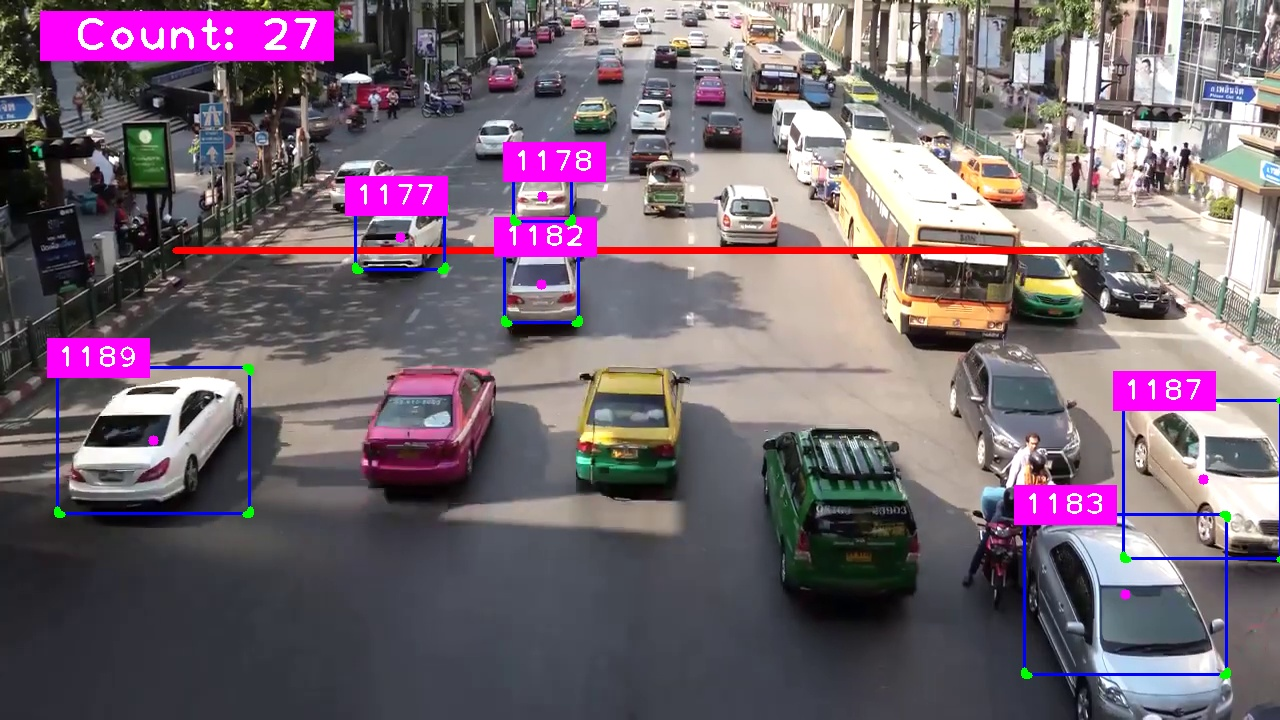


0: 640x640 1 bicycle, 10 cars, 6 buss, 2 trucks, 1 cell phone, 10.2ms
Speed: 0.0ms preprocess, 10.2ms inference, 18.3ms postprocess per image at shape (1, 3, 640, 640)
Interrupted by user


In [ ]:
from IPython import display
# campture the frame and detect
cap = cv2.VideoCapture("/content/drive/MyDrive/Object_detection/Dataset/sample_vdo_2.mp4")

# reading the property of the video
frame_width = int(cap.get(3))    # property 3 means width (pixels)
frame_height = int(cap.get(4))   # property 4 means height (pixels)
frame_fps = int(cap.get(5))      # property 5 means fps
print(f"Frame width: {frame_width}")
print(f"Frame height: {frame_height}")
print(f"Frame FPS: {frame_fps}")

# define codec and videowriter object (save frames into a video file)
"""out = cv2.VideoWriter("output_mask_track_final_count_cuda_normalized.mp4",                          # output file name and format
                      cv2.VideoWriter_fourcc(*'mp4v'),       # video compression format
                      frame_fps, (frame_width, frame_height) # same properties
                      )
print(f"VideoWriter created: output_mask_track_final_count_cuda_normalized.mp4 with codec {'mp4v'} at {frame_fps} FPS and resolution ({frame_width}, {frame_height})")
   """
mask = cv2.imread("/content/drive/MyDrive/Object_detection/Dataset/mask.png")
limits = [175,250, 1100, 250]
totalCount = []
try:
    frame_count = 0
    while True:
        success, img = cap.read()
        if not success:  # Check if the frame was read successfully
            print("Failed to read frame from video stream. Ending video processing.")
            break  # Exit the loop if reading failed
        imgRegion = cv2.bitwise_and(img, mask)
        frame_count += 1

        # Resize imgRegion to 640x640 before processing with the model
        imgRegion_resized = cv2.resize(imgRegion, (640, 640))

        # Convert the resized image to a PyTorch tensor and move it to the GPU and normalize
        imgRegion_tensor = torch.from_numpy(imgRegion_resized).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0

        results = model(imgRegion_tensor)
        detections = np.empty((0, 5))
        for r in results:
            boxes = r.boxes
            for box in boxes:
                #x1, y1, x2, y2 = box.xyxy[0]
                #x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                #print(x1, y1, x2, y2)
                #cv2.rectangle(img, (x1, y1), (x2, y2), (255,0, 255), 3)   # image, (x1, y1), (x2, y2), (color in rgb), width


                # if you want to use cvzone for fancy recatnge
                # The box coordinates are relative to the resized image (640x640).
                # We need to scale them back to the original image dimensions (frame_width, frame_height)
                x1, y1 , x2 , y2 = box.xyxy[0]
                # Scale coordinates back to original frame size
                x1, y1, x2, y2 = int(x1 * frame_width / 640), int(y1 * frame_height / 640), int(x2 * frame_width / 640), int(y2 * frame_height / 640)
                w, h = x2-x1, y2-y1

                # confidence
                conf = math.ceil(box.conf[0]*100)/100
                #print(conf)
                #cvzone.putTextRect(img, f'{conf}{total_class[clls]}', (max(0,x1),max(30,y1)))
                # class
                clls = int(box.cls[0])
                current_class = total_class[clls]
                if current_class == "car" and conf > 0.3:
                  #cvzone.cornerRect(img, (x1, y1, w, h)) # This cornerRect was for displaying detection boxes, we'll replace it with tracking boxes
                  #cvzone.putTextRect(img, f'{conf}{total_class[clls]}', (max(0,x1),max(30,y1)), scale=0.5, thickness=1) # This text was for displaying detection info, we'll replace it with tracking ID
                  currentArray = np.array([x1, y1, x2, y2, conf])
                  detections = np.vstack((detections, currentArray))

        results = tracker.update(detections)
        cv2.line(img, (limits[0],limits[1]),(limits[2],limits[3]),(0,0,255),5)
        for result in results:
          x1, y1, x2, y2, id = result
          x1, y1, x2, y2, id = int(x1), int(y1), int(x2), int(y2), int(id)
          w, h = x2-x1, y2-y1
          cx,cy = x1 + w//2, y1 + h//2
          cv2.circle(img, (cx,cy), 5, (255,0,255), cv2.FILLED)
          if limits[0] < cx < limits[2] and limits[1]-15 < cy < limits[3]+15:
            if totalCount.count(id)==0:
              totalCount.append(id)
              cv2.line(img, (limits[0],limits[1]),(limits[2],limits[3]),(0,255,0),5)
          cvzone.cornerRect(img, (x1, y1, w, h), l=5, rt=2, colorR=(255,0,0))
          cvzone.putTextRect(img, f'{id}', (max(0,x1),max(30,y1)), scale=2, thickness=2, offset=10) # Adjusted scale and thickness for visibility
          cvzone.putTextRect(img, f' Count: {len(totalCount)}', (50,50))
        img = cv2.resize(img, (frame_width, frame_height))
        _, ret_img = cv2.imencode('.jpeg', img)
        display.clear_output(wait=True)
        display.display(display.Image(data=ret_img.tobytes()))
        if frame_count % 100 == 0:  # Print every 100 frames to avoid too much output
            print(f"Processed and wrote frame {frame_count}")

except KeyboardInterrupt:
    print("Interrupted by user")
finally:
    cap.release()
    out.release() # Release the VideoWriter
    cv2.destroyAllWindows()